# SEMANA 7: REGRESIÓN LOGÍSTICA. MÁQUINAS DE VECTOR DE SOPORTE

### Con base a datos de cáncer de mama alojados en el repositorio UCI Machine Learning Repository y utilizando las librerías de Python que se indican, haga lo siguiente:

### a. Calcule el information value (IV), tanto para el grupo de variable numéricas como categóricas y excluya las que tenga un poder predictivo débil o menor. Además, separe la variable de clasificación del resto de variables para luego obtener los datos de entrenamiento y prueba, tomando de este último el 25% de datos.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


# URL del dataset (formato de datos separados por comas)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data"

# Nombres de las columnas según la descripción del dataset
column_names = [
    "ID", "Clump_Thickness", "Uniformity_Cell_Size", "Uniformity_Cell_Shape",
    "Marginal_Adhesion", "Single_Epithelial_Cell_Size", "Bare_Nuclei",
    "Bland_Chromatin", "Normal_Nucleoli", "Mitoses", "Class"
]

# Leer los datos
df = pd.read_csv(url, header=None, names=column_names)

# Mostrar el dataframe
df


,ID,Clump_Thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...
694,776715,3,1,1,1,3,2,1,1,1,2
695,841769,2,1,1,1,2,1,1,1,1,2
696,888820,5,10,10,3,7,3,8,10,2,4
697,897471,4,8,6,4,3,4,10,6,1,4


In [3]:

import numpy as np
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
# Reemplazar los signos de interrogación por valores faltantes (NaN)
df.replace("?", np.nan, inplace=True)

# Ver cuántos valores faltan por columna
print(df.isnull().sum())


ID                              0
Clump_Thickness                 0
Uniformity_Cell_Size            0
Uniformity_Cell_Shape           0
Marginal_Adhesion               0
Single_Epithelial_Cell_Size     0
Bare_Nuclei                    16
Bland_Chromatin                 0
Normal_Nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64


In [5]:
# Convertimos a tipo numérico (float) para poder imputar
df["Bare_Nuclei"] = pd.to_numeric(df["Bare_Nuclei"])

# Imputar los valores faltantes con la mediana de cada columna
imputer = SimpleImputer(strategy="median")
df.iloc[:, 1:-1] = imputer.fit_transform(df.iloc[:, 1:-1])

# Ver cuántos valores faltan por columna
print(df.isnull().sum())

ID                             0
Clump_Thickness                0
Uniformity_Cell_Size           0
Uniformity_Cell_Shape          0
Marginal_Adhesion              0
Single_Epithelial_Cell_Size    0
Bare_Nuclei                    0
Bland_Chromatin                0
Normal_Nucleoli                0
Mitoses                        0
Class                          0
dtype: int64


In [7]:
# Separar las variables predictoras de la variable objetivo (Class)
X = df.drop(['ID', 'Class'], axis=1)  # Variables predictoras
y = df['Class']  # Variable objetivo
# Codificar la variable objetivo (si es necesario: 2 = benigno, 4 = maligno)
le = LabelEncoder()
y = le.fit_transform(y)


In [9]:
# Función para calcular el Information Value (IV)
def calculate_iv(X, y):
    iv_dict = {}
    
    for column in X.columns:
        if X[column].dtype == 'object' or len(X[column].unique()) < 10:
            # Para variables categóricas o con pocos valores únicos
            value_counts = X[column].value_counts()
            iv = 0
            for val, count in value_counts.items():
                # Calcular la probabilidad de cada categoría en relación con la clase
                dist_0 = np.sum((y == 0) & (X[column] == val)) / len(y)
                dist_1 = np.sum((y == 1) & (X[column] == val)) / len(y)
                if dist_0 == 0 or dist_1 == 0:
                    iv += 0
                else:
                    iv += (dist_0 - dist_1) * np.log((dist_0 + 1e-10) / (dist_1 + 1e-10))  # Añadir 1e-10 para evitar log(0)
            iv_dict[column] = iv
        else:
            # Para variables numéricas: dividir en bins (categorizar)
            bins = pd.cut(X[column], bins=10, include_lowest=True)
            iv = 0
            for bin in bins.unique():
                dist_0 = np.sum((y == 0) & (bins == bin)) / len(y)
                dist_1 = np.sum((y == 1) & (bins == bin)) / len(y)
                if dist_0 == 0 or dist_1 == 0:
                    iv += 0
                else:
                    iv += (dist_0 - dist_1) * np.log((dist_0 + 1e-10) / (dist_1 + 1e-10))  # Añadir 1e-10 para evitar log(0)
            iv_dict[column] = iv
    
    return iv_dict


In [11]:
# Calcular IV para todas las variables
iv_dict = calculate_iv(X, y)

# Mostrar el IV de cada variable
iv_df = pd.DataFrame(list(iv_dict.items()), columns=['Variable', 'IV'])
print(iv_df)


                      Variable        IV
0              Clump_Thickness  1.560059
1         Uniformity_Cell_Size  2.843589
2        Uniformity_Cell_Shape  3.126509
3            Marginal_Adhesion  1.650116
4  Single_Epithelial_Cell_Size  2.124360
5                  Bare_Nuclei  2.518022
6              Bland_Chromatin  2.100137
7              Normal_Nucleoli  1.527707
8                      Mitoses  0.727522


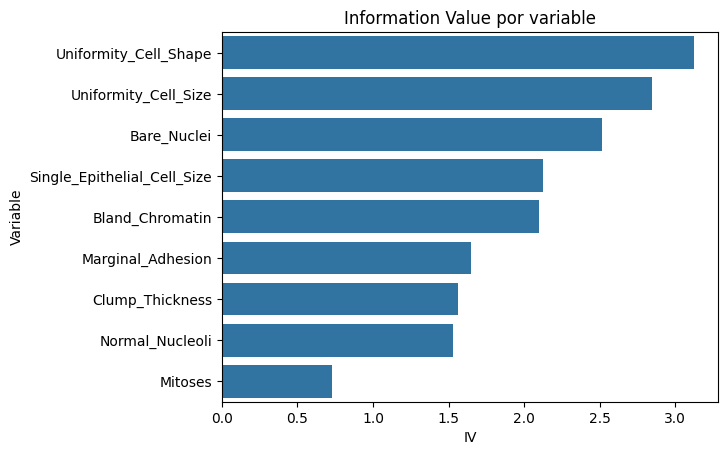

In [13]:
# Excluir las variables con IV bajo (por ejemplo, IV < 0.02)
threshold = 0.02
strong_predictors = iv_df[iv_df['IV'] >= threshold]['Variable'].tolist()

# Filtrar X para mantener solo las variables con IV alto
X_filtered = X[strong_predictors]
# Visualización de los IV
sns.barplot(x="IV", y="Variable", data=iv_df.sort_values("IV", ascending=False))
plt.title("Information Value por variable")
plt.show()

In [15]:
# Dividir en entrenamiento y prueba (75% - 25%)
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y, test_size=0.25, random_state=42)

# Mostrar los resultados
print(f"Variables seleccionadas: {strong_predictors}")
print(f"Forma de X_train: {X_train.shape}")
print(f"Forma de X_test: {X_test.shape}")


Variables seleccionadas: ['Clump_Thickness', 'Uniformity_Cell_Size', 'Uniformity_Cell_Shape', 'Marginal_Adhesion', 'Single_Epithelial_Cell_Size', 'Bare_Nuclei', 'Bland_Chromatin', 'Normal_Nucleoli', 'Mitoses']
Forma de X_train: (524, 9)
Forma de X_test: (175, 9)


#### En este análisis, trabajamos con el conjunto de datos de cáncer de mama de Wisconsin, el cual contiene información clínica de muestras celulares para clasificar tumores como benignos o malignos. Tras cargar y limpiar los datos, se imputaron valores faltantes y se transformaron adecuadamente las variables, especialmente la columna Bare_Nuclei, que contenía valores no numéricos. A continuación, se calculó el Information Value (IV) para evaluar el poder predictivo de cada variable en relación con la clase objetivo (Class). De las 9 variables predictoras analizadas (excluyendo el ID), todas superaron el umbral mínimo de IV (0.02), lo que indica que tienen al menos una capacidad predictiva moderada o fuerte. Finalmente, el conjunto de datos se dividió en conjuntos de entrenamiento (75%) y prueba (25%), manteniendo estas 9 variables relevantes. Este preprocesamiento y selección de variables sientan una base sólida para entrenar modelos de machine learning con el objetivo de predecir de manera precisa la naturaleza del tumor.

### b. Genere el modelo de regresión logística y evalúe la exclusión de variables mediante la significancia de los coeficientes. Además, calcule las métricas de clasificación que se implementaron en la parte práctica e interprete sus resultados más importantes.

In [61]:
import statsmodels.api as sm

# Agregar constante para el intercepto
X_train_const = sm.add_constant(X_train)

# Crear y ajustar el modelo
logit_model = sm.Logit(y_train, X_train_const)
result = logit_model.fit()

# Mostrar resumen del modelo (coeficientes y significancia)
print(result.summary())


Optimization terminated successfully.
         Current function value: 0.082602
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  524
Model:                          Logit   Df Residuals:                      514
Method:                           MLE   Df Model:                            9
Date:                Wed, 30 Apr 2025   Pseudo R-squ.:                  0.8726
Time:                        21:15:22   Log-Likelihood:                -43.283
converged:                       True   LL-Null:                       -339.63
Covariance Type:            nonrobust   LLR p-value:                7.732e-122
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                          -9.6225      1.206     -7.979      0.000   

### Se entrenó un modelo de regresión logística utilizando todas las variables seleccionadas previamente mediante Information Value, y se evaluó la significancia estadística de cada una a través del análisis de los coeficientes. El modelo mostró un ajuste excelente, con un Pseudo R² de 0.8726 y un valor p global extremadamente bajo, lo que indica que en conjunto, las variables explican muy bien la variabilidad de la variable objetivo (diagnóstico benigno o maligno). Sin embargo, solo tres variables (Clump_Thickness, Bare_Nuclei y Bland_Chromatin) resultaron estadísticamente significativas (p < 0.05), mientras que el resto no mostró evidencia suficiente para afirmar que influyen individualmente en la predicción del diagnóstico. Esto sugiere que el modelo podría simplificarse eliminando las variables no significativas, sin comprometer necesariamente su desempeño predictivo, mejorando así la interpretabilidad y eficiencia del modelo.

In [63]:
# Predecir y evaluar el modelo

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Entrenar el modelo con scikit-learn
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predicciones
y_pred = model.predict(X_test)

# Evaluar métricas
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.96
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.98      0.97       118
           1       0.96      0.91      0.94        57

    accuracy                           0.96       175
   macro avg       0.96      0.95      0.95       175
weighted avg       0.96      0.96      0.96       175

Confusion Matrix:
 [[116   2]
 [  5  52]]


#### Al evaluar el modelo de regresión logística, obtuve una precisión del 96%, lo que indica un muy buen desempeño general. La matriz de confusión muestra que de los 118 casos benignos, el modelo clasificó correctamente 116, cometiendo solo 2 errores. En los 57 casos malignos, logró predecir correctamente 52, aunque cometió 5 falsos negativos, lo cual es importante considerar dado que estos representan casos de cáncer que no fueron detectados. En cuanto a las métricas, obtuve un recall del 91% y una precisión del 96% para la clase maligna, lo que indica que el modelo es bastante efectivo, aunque podría mejorar en la detección de casos positivos. En resumen, estoy satisfecho con el rendimiento del modelo, pero considero que se pueden implementar mejoras para reducir los falsos negativos, especialmente por la relevancia clínica del problema.

### C. Genere el modelo SVM, calcule sus métricas de clasificación y compárelas con las del modelo de regresión logística para ver si hubo o no mejoras.

In [20]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Crear el modelo SVM con kernel lineal (puedes probar otros como 'rbf' también)
svm_model = SVC(kernel='linear', probability=True)
svm_model.fit(X_train, y_train)

# Predecir
y_svm_pred = svm_model.predict(X_test)

# Evaluar
print("=== SVM ===")
print("Accuracy:", accuracy_score(y_test, y_svm_pred))
print("Classification Report:\n", classification_report(y_test, y_svm_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_svm_pred))


=== SVM ===
Accuracy: 0.9657142857142857
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.97       118
           1       0.96      0.93      0.95        57

    accuracy                           0.97       175
   macro avg       0.97      0.96      0.96       175
weighted avg       0.97      0.97      0.97       175

Confusion Matrix:
 [[116   2]
 [  4  53]]


In [27]:
print("=== Comparación de Modelos ===")

# Accuracy
acc_log = accuracy_score(y_test, y_log_pred)
acc_svm = accuracy_score(y_test, y_svm_pred)

print(f"Accuracy Logística: {acc_log:.2f}")
print(f"Accuracy SVM:       {acc_svm:.2f}")

# Matriz de confusión para ambos
print("\nMatriz de confusión - Logística:\n", confusion_matrix(y_test, y_log_pred))
print("\nMatriz de confusión - SVM:\n", confusion_matrix(y_test, y_svm_pred))


=== Comparación de Modelos ===
Accuracy Logística: 0.96
Accuracy SVM:       0.97

Matriz de confusión - Logística:
 [[116   2]
 [  5  52]]

Matriz de confusión - SVM:
 [[116   2]
 [  4  53]]


#### Al comparar los modelos de regresión logística y SVM, observé que el modelo SVM logró una ligera mejora en la precisión general, pasando de 96% a 97% de accuracy. Ambas matrices de confusión muestran un desempeño muy similar en la clasificación de casos benignos (116 verdaderos negativos y 2 falsos positivos), pero el modelo SVM redujo los falsos negativos de 5 a 4 en la clase maligna, lo cual es importante en contextos médicos donde no detectar un caso maligno puede tener consecuencias graves. Además, el SVM identificó correctamente un caso maligno más que la regresión logística. En resumen, aunque ambos modelos son bastante efectivos, el SVM ofrece un rendimiento ligeramente superior, especialmente en la detección de casos de cáncer maligno.